# **Regression Model Exploration**

The following book explores various regression models to be used to predict the permanent magnet temperature in a PM motor.

## **Imports**

In [69]:
# Standard library imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# SkLearn preprocessing imports
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_validate, GridSearchCV, train_test_split, RepeatedKFold, learning_curve
from sklearn.feature_selection import RFECV
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, make_scorer

# SkLearn model imports
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.svm import SVR, LinearSVR
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.utils.validation import check_is_fitted


In [70]:
# # Machine Learning library imports
import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from tensorflow.keras import layers
from keras.layers import Dense, BatchNormalization, Dropout
from keras.optimizers import Adam, SGD, RMSprop, Adadelta, Adagrad, Adamax, Nadam, Ftrl
from keras.callbacks import EarlyStopping, ModelCheckpoint
from scikeras.wrappers import KerasClassifier, KerasRegressor
from tensorflow.keras.layers import LeakyReLU
from functools import partial
from tensorflow.keras import models
from tensorflow.keras.activations import swish

# #Other library imports
from bayes_opt import BayesianOptimization
from pandas.plotting import parallel_coordinates

In [71]:
pd.set_option('display.max_colwidth', None)  # Prevent column truncation
pd.set_option('display.expand_frame_repr', False)  # Prevent line wrapping
pd.set_option('display.max_columns', None)  # Show all columns
pd.set_option('display.max_rows', None)  # Show all rows

## **Data Manipulation and Preprocessing**

First we load the data, then drop unnecessary columns, and then reorder the columns to group by similarity.

In [72]:
df = pd.read_csv('measures_v2.csv')
df.head()

,u_q,coolant,stator_winding,u_d,stator_tooth,motor_speed,i_d,i_q,pm,stator_yoke,ambient,torque,profile_id
0,-0.450682,18.805172,19.086670,-0.350055,18.293219,0.002866,0.004419,0.000328,24.554214,18.316547,19.850691,0.187101,17
1,-0.325737,18.818571,19.092390,-0.305803,18.294807,0.000257,0.000606,-0.000785,24.538078,18.314955,19.850672,0.245417,17
2,-0.440864,18.828770,19.089380,-0.372503,18.294094,0.002355,0.001290,0.000386,24.544693,18.326307,19.850657,0.176615,17
3,-0.327026,18.835567,19.083031,-0.316199,18.292542,0.006105,0.000026,0.002046,24.554018,18.330833,19.850647,0.238303,17
4,-0.471150,18.857033,19.082525,-0.332272,18.291428,0.003133,-0.064317,0.037184,24.565397,18.326662,19.850639,0.208197,17


In [73]:
cols_to_drop = [
    'profile_id',
    # 'torque',
    'stator_tooth',
    'stator_winding'
]
columns_order = [
    'u_q', 
    'u_d', 
    'i_q', 
    'i_d',
    'torque',
    'motor_speed', 
    'ambient', 
    'coolant', 
    'stator_yoke', 
    'pm'
]

df = df.drop(cols_to_drop, axis=1)
df = df[columns_order]
df = df.dropna()
df.head()

,u_q,u_d,i_q,i_d,torque,motor_speed,ambient,coolant,stator_yoke,pm
0,-0.450682,-0.350055,0.000328,0.004419,0.187101,0.002866,19.850691,18.805172,18.316547,24.554214
1,-0.325737,-0.305803,-0.000785,0.000606,0.245417,0.000257,19.850672,18.818571,18.314955,24.538078
2,-0.440864,-0.372503,0.000386,0.001290,0.176615,0.002355,19.850657,18.828770,18.326307,24.544693
3,-0.327026,-0.316199,0.002046,0.000026,0.238303,0.006105,19.850647,18.835567,18.330833,24.554018
4,-0.471150,-0.332272,0.037184,-0.064317,0.208197,0.003133,19.850639,18.857033,18.326662,24.565397


In [74]:
df = df.sample(frac=0.05, random_state=42)

Now let's split our dataset into the feature set `X` and label set `y`.

In [75]:
X = df.drop('pm', axis=1)
y = df['pm']

Next we'll split the data into a training and test set.

In [76]:
TEST_SIZE = 0.3

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=TEST_SIZE, random_state=42)

In [77]:
print(f'X_train shape: {X_train.shape}')
print(f'X_test shape: {X_test.shape}')

X_train shape: (46578, 9)
X_test shape: (19963, 9)


Now we'll make a pipeline that scales the data. 

In [78]:
data_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    # ('pca', PCA(n_components=4))
])

## **Baseline Model Exploration**

### **Models Explored**

**DummyRegressor**
- Serves as a baseline reference model by predicting a constant value (e.g., the mean of the training data)
- Useful for benchmarking the minimum level of performance that any proceeding model should surpass
- Helps identify potential issues in data preprocessing or modeling pipelines if more complex models do not outperform it

**LinearRegression**
- Provides a simple and interpretable baseline for modeling linear relationships between features and the target
- Assumes linearity and independence of errors allowing for quick diagnostic assessment of the data
- Offers insight into feature contributions via coefficient values, aiding in feature selection and understanding model behavior

**Ridge Regression (L2 Regularization)**
- Extends linear regression by penalizing large coefficients, helping to mitigate multicollinearity and overfitting
- Particularly appropriate for this dataset, where high correlation among stator temperature features (e.g., `stator_tooth`, `stator_winding`) exists
- Useful when most features are believed to contribute to the prediction, but their influence may be small and correlated

**Lasso Regression (L1 Regularization)**
- Introduces a sparsity-inducing penalty that can reduce coefficients to zero, effectively performing automatic feature selection
- Well-suited for identifying a model that retains only the most informative features
- Helps interpret which variables are most influential while removing those with minimal or redundant impact

**ElasticNet**
- Combines the strengths of both Ridge and Lasso by balancing L1 and L2 regularization
- Effective when there are highly correlated features and when the model needs both stability and sparsity
- Provides a flexible regularization framework that can adapt to different data conditions better than Ridge or Lasso alone

**Support Vector Regressor (SVR)**
- A non-linear model capable of learning complex relationships via kernel functions (e.g., RBF kernel)
- Suitable for scenarios where the relationship between features and target (`pm`) may be non-linear, as suggested by pair plots
- Robust to outliers and particularly useful for datasets with non-Gaussian distributions and non-linear margins

### **Evaluation Metrics**

**Mean Absolute Error (MAE)**
- Measures the average magnitude of errors between predicted and actual values, regardless of direction
- Defined as: $ \text{MAE} = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i| $
- **Motivation**:
  - Intuitive and interpretable (in same units as the target) baseline for average performance
  - Less sensitive to outliers compared to MSE
  - Preferred when the goal is to minimize prediction error

**Mean Squared Error (MSE)**
- Measures the **average of squared errors**, giving greater weight to larger deviations
- Defined as: $ \text{MSE} = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 $
- **Motivation**:
  - Emphasizes large deviations and is ideal for identifying models that produce occasional large errors
  - Penalizes high-variance predictions more heavily

**Coefficient of Determination (R² Score)**
- Represents the proportion of variance in the target explained by the model
- Defined as: $ R^2 = 1 - \frac{\sum (y_i - \hat{y}_i)^2}{\sum (y_i - \bar{y})^2} $
- **Motivation**:
  - Provides an overall view of explanatory strength, helping to contextualize absolute errors within the variability of the data
  - A value near 1 indicates high predictive power; near 0 suggests performance equivalent to a mean-only model

Let's define a function to train multiple models and output their results as a dataframe by first performing grid search for hyperparameter optimization, then cross-validation to evaluate the training of the models.

In [79]:
def train_multi_models(models: dict, param_grids: dict, metrics: list, X_train: pd.DataFrame, y_train: pd.Series):
    results = []
    for name, model in models.items():
        print(f'Running cross-validation for model: {name}')
        model_pipeline = Pipeline([
            ('data_processing', data_pipeline),
            ('model', model)
        ])

        if name in param_grids:
            grid_search = GridSearchCV(
                model_pipeline,
                param_grid = param_grids[name],
                scoring = metrics,
                refit = 'neg_mean_absolute_error',
                cv = 5
            )
            grid_search.fit(X_train, y_train)
            best_pipeline = grid_search.best_estimator_
            best_params = grid_search.best_params_
        else:
            best_pipeline = model_pipeline
            best_pipeline.fit(X_train, y_train)
            best_params = None
        
        scores = cross_validate(
            best_pipeline,
            X_train,
            y_train,
            scoring=metrics,
            cv = 5,
            return_train_score=True
        )

        results.append({
            'Model': name,
            'Train MAE': -np.mean(scores['train_neg_mean_absolute_error']),
            'Validation MAE': -np.mean(scores['test_neg_mean_absolute_error']),
            'Train MSE': -np.mean(scores['train_neg_mean_squared_error']),
            'Validation MSE': -np.mean(scores['test_neg_mean_squared_error']),
            'Train R²': np.mean(scores['train_r2']),
            'Validation R²': np.mean(scores['test_r2'])
        })
    
    print('Training complete!')

    results_df = pd.DataFrame(results)
    return(results_df)

In [80]:
models = {
    'Dummy Regressor' : DummyRegressor(strategy='mean'),
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(),
    'Lasso': Lasso(),
    'ElasticNet': ElasticNet(),
    # 'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42)
    'SVR': LinearSVR()
}

param_grids = {
    'Ridge': {'model__alpha': [0.1, 1.0, 10.0, 100.0]},
    'Lasso': {'model__alpha': [0.01, 0.1, 1.0, 10.0]},
    'ElasticNet': {
        'model__alpha': [0.01, 0.1, 1.0],
        'model__l1_ratio': [0.2, 0.5, 0.8]
    }
}

scoring_metrics = [
    'neg_mean_absolute_error',
    'neg_mean_squared_error',
    'r2'
]

In [81]:
baseline_model_results = train_multi_models(models, param_grids, scoring_metrics, X_train, y_train)
baseline_model_results

Running cross-validation for model: Dummy Regressor
Running cross-validation for model: Linear Regression
Running cross-validation for model: Ridge
Running cross-validation for model: Lasso
Running cross-validation for model: ElasticNet
Running cross-validation for model: SVR
Training complete!


,Model,Train MAE,Validation MAE,Train MSE,Validation MSE,Train R²,Validation R²
0,Dummy Regressor,15.894498,15.894767,360.430338,360.444757,0.000000,-0.000101
1,Linear Regression,6.033285,6.035605,64.115478,64.159036,0.822113,0.821962
2,Ridge,6.033297,6.035616,64.115478,64.159026,0.822113,0.821962
3,Lasso,6.037319,6.039358,64.160967,64.197327,0.821987,0.821856
4,ElasticNet,6.050655,6.052675,64.248577,64.284670,0.821744,0.821614
5,SVR,5.902449,5.906809,66.694289,66.738134,0.814958,0.814804


## **Baseline Model Results**

**Dummy Regressor**
- **Train MAE / Validation MAE**: ~15.89
- **R² Score**: ~0 (train), slightly negative on validation
- Acts as an expected low-performance benchmark with all models substantially outperforming it, confirming that learned patterns are meaningful and not random

**Linear Regression**
- **Validation MAE**: 6.04, **Validation R²**: 0.82
- Provides a strong baseline with low error and high variance explanation
- The closeness of training and validation scores suggests that there is good generalization with no overfitting

**Ridge Regression**
- Identical performance to Linear Regression indicating that L2 regularization has minimal effect, likely due to already well-conditioned feature space or minimal multicollinearity impact

**Lasso Regression**
- Slightly higher MAE and MSE compared to Ridge and Linear Regression
- Very small performance degradation suggests marginal sparsity was enforced, potentially at the cost of removing slightly informative features which might be beneficial if interpretability or feature reduction is prioritized

**ElasticNet**
- **Validation MAE**: 6.05, nearly matching Ridge and Lasso
- Offers a balance between sparsity and shrinkage but does not significantly improve over Ridge or Lasso in this case
- Best suited for future use if regularization tuning shows instability between L1 and L2 needs

**Support Vector Regressor (SVR)**
- Lowest Validation MAE: **5.91**
- Highest validation generalization across models (while slightly lower R²: **0.815**)
- Demonstrates that non-linear modeling does in fact capture some small nuances missed by linear models
- Slightly higher train MSE suggests less overfitting, but there is still potential room for kernel or hyperparameter tuning

**Summary of Key Insights**
- All models significantly outperform the Dummy Regressor, validating the predictive power of the features
- Linear and Ridge Regression perform almost identically and generalize well.
- SVR offers the good predictive accuracy, supporting earlier insights about non-linearity in the feature-target relationship
- Lasso and ElasticNet introduce slight trade-offs which could be valuable in feature selection or when extending the model to larger feature spaces

## **Feature Reduction using Recursive Feature Elimination**

Running machine learning models is computationally expensive and becomes more demanding the larger the dataset. With over 1 Million datapoints and 9 features, it is important to reduce the number of features used in the dataset. Furthermore, it is useful to understand the importance of each feature when predicting outputs within both a linear and non-linear model. This is why a wrapper method was applied to determine the best combination of features which would provide an optimal accuracy with the use of a strategy called Recursive Feature Elimination (RFE). RFE is a technique used to provide specific number of features required for adequate performance through importance. It does so by including all the features within the dataset and ranking them based on either their importance or contribution to accuracy. It removes the insignificant features and outputs the optimal number of features required. Exhaustive search explores every combination possibility within the features and determines the best set for accuracy. An issue with this is that it is computationally expensive due to the plethora of features contributed by the chosen dataset but only requires us to do so once before hypertuning ML models. The models chosen for feature selection importance were Linear Regression and Random Forest Regression.  

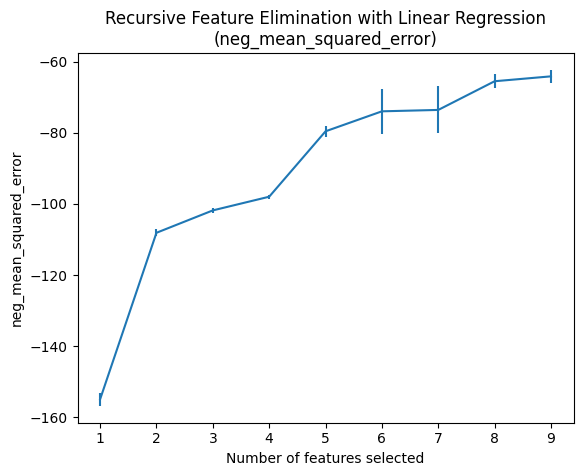

Optimal number of features: 9
Selected features: Index(['u_q', 'u_d', 'i_q', 'i_d', 'torque', 'motor_speed', 'ambient',
       'coolant', 'stator_yoke'],
      dtype='object')
Feature rankings: [1 1 1 1 1 1 1 1 1]

Feature Selection Process:

With 1 features, Score = -154.8973
Selected Features: [np.str_('u_q')]
--------------------------------------------------
With 2 features, Score = -108.1085
Selected Features: [np.str_('u_q'), np.str_('u_d')]
--------------------------------------------------
With 3 features, Score = -101.8199
Selected Features: [np.str_('u_q'), np.str_('u_d'), np.str_('i_q')]
--------------------------------------------------
With 4 features, Score = -97.9764
Selected Features: [np.str_('u_q'), np.str_('u_d'), np.str_('i_q'), np.str_('i_d')]
--------------------------------------------------
With 5 features, Score = -79.5985
Selected Features: [np.str_('u_q'), np.str_('u_d'), np.str_('i_q'), np.str_('i_d'), np.str_('torque')]
-------------------------------------

In [82]:
model = LinearRegression()
scoring_metrics = ['neg_mean_absolute_error', 'r2']
results = []
min_features_to_select = 1
cv = 5

model_pipeline = Pipeline([
    ('data_processing', data_pipeline),  
    ('feature_selection', RFECV(
        estimator=model,  #
        step=1,
        cv=cv,
        scoring="neg_mean_squared_error",
        min_features_to_select=min_features_to_select,
        n_jobs=2
    )),
    ('model', model)  
])

model_pipeline.fit(X_train, y_train)
rfecv = model_pipeline.named_steps['feature_selection']
y_pred = model_pipeline.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

results.append({
    'Model': model,
    'MSE': mse,
    'MAE': mae,
    'RMSE': rmse,
    'R²': r2,
    'Optimal Features': rfecv.n_features_
})

plt.figure()
plt.xlabel("Number of features selected")
plt.ylabel("neg_mean_squared_error")
plt.errorbar(
    range(min_features_to_select, len(rfecv.cv_results_["mean_test_score"]) + min_features_to_select),
    rfecv.cv_results_["mean_test_score"],
    yerr=rfecv.cv_results_["std_test_score"],
)
plt.title("Recursive Feature Elimination with Linear Regression\n(neg_mean_squared_error)")
plt.show()

print(f"Optimal number of features: {rfecv.n_features_}")
print(f"Selected features: {X.columns[rfecv.support_]}")
print(f"Feature rankings: {rfecv.ranking_}")
print()

mean_scores = rfecv.cv_results_["mean_test_score"]
features = list(X.columns)
ranking = np.array(rfecv.ranking_)

sorted_indices = np.argsort(ranking)
sorted_features = np.array(features)[sorted_indices]

selected_features = list(sorted_features)

print("Feature Selection Process:\n")
for num_features in range(1, len(features) + 1):
    score = mean_scores[num_features - 1]

    print(f"With {num_features} features, Score = {score:.4f}")
    print(f"Selected Features: {selected_features[:num_features]}")
    print("-" * 50)

results_df_RFECV_LR = pd.DataFrame(results)
print(results_df_RFECV_LR)


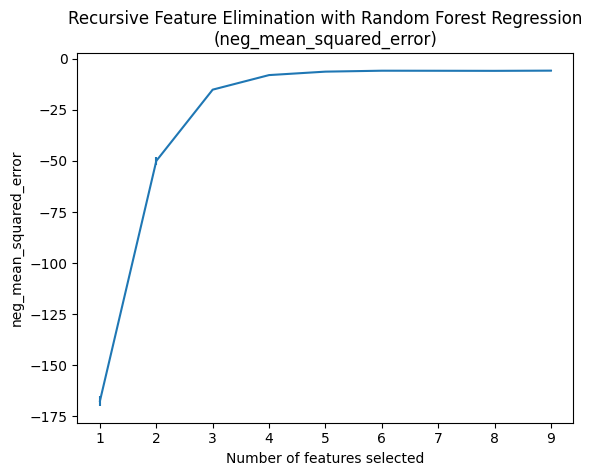

Optimal number of features: 9
Selected features: Index(['u_q', 'u_d', 'i_q', 'i_d', 'torque', 'motor_speed', 'ambient',
       'coolant', 'stator_yoke'],
      dtype='object')
Feature rankings: [1 1 1 1 1 1 1 1 1]

Feature Selection Process:

With 1 features, Score = -167.4083
Selected Features: [np.str_('u_q')]
--------------------------------------------------
With 2 features, Score = -49.9668
Selected Features: [np.str_('u_q'), np.str_('u_d')]
--------------------------------------------------
With 3 features, Score = -15.1213
Selected Features: [np.str_('u_q'), np.str_('u_d'), np.str_('i_q')]
--------------------------------------------------
With 4 features, Score = -7.9947
Selected Features: [np.str_('u_q'), np.str_('u_d'), np.str_('i_q'), np.str_('i_d')]
--------------------------------------------------
With 5 features, Score = -6.3081
Selected Features: [np.str_('u_q'), np.str_('u_d'), np.str_('i_q'), np.str_('i_d'), np.str_('torque')]
-----------------------------------------

In [85]:
model = RandomForestRegressor()

scoring_metrics = ['neg_mean_absolute_error', 'r2']
results = []
min_features_to_select = 1
cv = 5

model_pipeline = Pipeline([
    ('data_processing', data_pipeline),  
    ('feature_selection', RFECV(
        estimator=model, 
        step=1,
        cv=cv,
        scoring="neg_mean_squared_error",
        min_features_to_select=min_features_to_select,
        n_jobs=2
    )),
    ('model', model)  
])
model_pipeline.fit(X_train, y_train)
rfecv = model_pipeline.named_steps['feature_selection']
y_pred = model_pipeline.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

results.append({
    'Model': model,
    'MSE': mse,
    'MAE': mae,
    'RMSE': rmse,
    'R²': r2,
    'Optimal Features': rfecv.n_features_
})

plt.figure()
plt.xlabel("Number of features selected")
plt.ylabel("neg_mean_squared_error")
plt.errorbar(
    range(min_features_to_select, len(rfecv.cv_results_["mean_test_score"]) + min_features_to_select),
    rfecv.cv_results_["mean_test_score"],
    yerr=rfecv.cv_results_["std_test_score"],
)
plt.title("Recursive Feature Elimination with Random Forest Regression\n(neg_mean_squared_error)")
plt.show()

print(f"Optimal number of features: {rfecv.n_features_}")
print(f"Selected features: {X.columns[rfecv.support_]}")
print(f"Feature rankings: {rfecv.ranking_}")
print()

mean_scores = rfecv.cv_results_["mean_test_score"]
features = list(X.columns)
ranking = np.array(rfecv.ranking_)

sorted_indices = np.argsort(ranking)
sorted_features = np.array(features)[sorted_indices]

selected_features = list(sorted_features)

print("Feature Selection Process:\n")
for num_features in range(1, len(features) + 1):
    score = mean_scores[num_features - 1]

    print(f"With {num_features} features, Score = {score:.4f}")
    print(f"Selected Features: {selected_features[:num_features]}")
    print("-" * 50)


results_df_RFECV_RFR = pd.DataFrame(results)
pd.set_option('display.max_colwidth', None) 
pd.set_option('display.expand_frame_repr', False) 
pd.set_option('display.max_columns', None)  
pd.set_option('display.max_rows', None)  
print(results_df_RFECV_RFR)

**RFE with Linear Regressiong**
- The best NMSE score was given using all 9 features, indicating that Linear Regression does not work well with feature reduction and needs all of the features to capture the patterns within the data
- This is likely due to the linearity of the model being unable to capture the nuances of inter-feature non-linearities

**RFE with RFR**
- The best NMSE score was given using all 9 features, however there is little difference between using only 5 features and 9
- RFR does well with using any number of features between 5 and 9
- The five features selected were `u_q`, `u_d`, `i_q`, `i_d` and `torque`, indicating that the physical controls seem to have the most information regarding the PM temperature as compared to the remaining temperature features

## **Additional Algorithm Exploration**

Artificial neural networks (ANN) attempt to replicate a learning algorithm that simulates how neurons in human brains process information and are classified as supervised or unsupervised learning models. It can be classified under two general sets of techniques, a feedforward neural network (FNN) and a recurrent neural network (RNN) with a plethora of concepts derived from them. The differing point with RNN is that there is a delayed updating term within each node in the hidden layer. It is “self-taught” and updated using information provided from the layer and/or time increment before and is iterative over a larger model with more layers. For this report, a deep feed forward neural network (DFNN) is applied to the data. The DFNN architecture consists of an input layer, one or more hidden layers, and an output layer. This neural network begins by passing information from an input layer, through hidden layers containing “neurons” (nodes) deriving relationships between one another, and the output layer. It is considered deep because it contains more than 1 hidden layer, allowing it to capture high-level nuances in the data. It is named a FFN because it only provides the input in only one way and does not pass information from the output back through the neurons. An activation function is provided to both the hidden layers and the output to provide better correlation between the varying features. The batch size and epochs used within the model when selected allows for the number of test selections and training iterations that the model will undergo during the modelling process. 

Random Forest is a supervised machine-learning algorithm used for classification or regression tasks. It operates by constructing an ensemble of decision trees, where each tree is trained on a random subset of the training data and features. This random sampling with replacement ensures that each tree in the forest learns from a diverse subset of the data, reducing the risk of overfitting and improving generalization. At the core of Random Forest is the concept of bagging, where multiple decision trees are trained independently on different subsets of the data. During training, each tree is grown using a subset of the features selected randomly at each split, further enhancing diversity and reducing correlation between trees. Each tree in the forest independently predicts the outcome, and the final prediction is determined by aggregating the individual predictions of all trees. The goal is to harness the diversity of multiple trees to enhance predictive accuracy and mitigate overfitting. This technique is particularly effective in handling large datasets, high dimensionality, and intricate relationships within the data. However, its interpretability may be challenging due to its complexity.

### **Baseline RFR Model**

In [86]:
scoring = {
    'mse': make_scorer(mean_squared_error, greater_is_better=False),
    'mae': make_scorer(mean_absolute_error, greater_is_better=False),
    'r2': make_scorer(r2_score, greater_is_better=True)
}

def RF_model(X_train, y_train, X_test, y_test):
    #100 estimators, squred error, min sample leaf = 1, min sample split = 2, 
    rf_model = RandomForestRegressor()
    model_pipeline = Pipeline([
        ('data_processing', data_pipeline),
        ('model', rf_model)
    ])

    cv = 5
    scores = cross_validate(
        model_pipeline,
        X_train,
        y_train,
        scoring=scoring,
        cv=cv,
        return_train_score=True,
        n_jobs=2
    )

    model_pipeline.fit(X_train, y_train)
    y_pred = model_pipeline.predict(X_test)


    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

 
    results_RF = {
        'Train MSE': -np.mean(scores['train_mse']),
        'Validation MSE': -np.mean(scores['test_mse']),
        'Train MAE': -np.mean(scores['train_mae']),
        'Validation MAE': -np.mean(scores['test_mae']),
        'Train R²': np.mean(scores['train_r2']),
        'Validation R²': np.mean(scores['test_r2']),
        'Test MSE': mse,
        'Test MAE': mae,
        'Test RMSE': rmse,
        'Test R²': r2
    }

    results_df_RF = pd.DataFrame([results_RF])
    print("\nEvaluation Metrics:")
    print(results_df_RF)

    return mse, mae, rmse, r2, results_df_RF

### **Baseline ANN Model**

In [87]:
class KerasWrapper(BaseEstimator, RegressorMixin):
    def __init__(self, build_fn=None, epochs=100, batch_size=32, verbose=0):
        self.build_fn = build_fn
        self.epochs = epochs
        self.batch_size = batch_size
        self.verbose = verbose
        self.model_ = None
        
    def fit(self, X, y):
        self.model_ = self.build_fn()
        self.model_.fit(
            X, y,
            epochs=self.epochs,
            batch_size=self.batch_size,
            verbose=self.verbose,
            validation_split=0.2
        )
        return self
        
    def predict(self, X):
        check_is_fitted(self)
        return self.model_.predict(X).flatten()
    
    def __sklearn_is_fitted__(self):
        return hasattr(self, "model_") and self.model_ is not None

def create_ann(input_shape):
    model = tf.keras.Sequential([
        tf.keras.layers.InputLayer(input_shape=(input_shape,)),
        tf.keras.layers.Dense(10, activation='relu'),
        tf.keras.layers.Dense(8, activation='relu'),
        tf.keras.layers.Dense(1)
    ])
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

def ANN_model(X_train, y_train, X_test, y_test, cv=5):
    model_pipeline = Pipeline([
        ('data_processing', data_pipeline),
        ('model', KerasWrapper(
            build_fn=lambda: create_ann(X_train.shape[1]),
            epochs=100,
            batch_size=32,
            verbose=0
        ))
    ])

    scoring = {
        'neg_mse': 'neg_mean_squared_error',
        'neg_mae': 'neg_mean_absolute_error',
        'r2': 'r2'
    }

    model_pipeline.fit(X_train, y_train)
    
    cv_results = cross_validate(
        model_pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        return_train_score=True,
        error_score='raise'
    )

    train_mse = -np.mean(cv_results['train_neg_mse'])
    val_mse = -np.mean(cv_results['test_neg_mse'])
    train_mae = -np.mean(cv_results['train_neg_mae'])
    val_mae = -np.mean(cv_results['test_neg_mae'])
    train_r2 = np.mean(cv_results['train_r2'])
    val_r2 = np.mean(cv_results['test_r2'])


    y_pred = model_pipeline.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

 
    results_ANN = {
        'Train MSE': train_mse,
        'Validation MSE': val_mse,
        'Train MAE': train_mae,
        'Validation MAE': val_mae,
        'Train R²': train_r2,
        'Validation R²': val_r2,
        'Test MSE': mse,
        'Test MAE': mae,
        'Test RMSE': rmse,
        'Test R²': r2
    }

    results_df_ANN = pd.DataFrame([results_ANN])
    print("\nEvaluation Metrics:")
    print(results_df_ANN)

    return mse, mae, rmse, r2, results_df_ANN, cv_results

In [89]:
ann_mse, ann_mae, ann_rmse, ann_r2, results_df_ANN, cv_results = ANN_model(X_train, y_train, X_test, y_test)

print("ANN Metrics:")
print(f'MSE: {ann_mse:.4f}')
print(f'MAE: {ann_mae:.4f}')
print(f'RMSE: {ann_rmse:.4f}')
print(f'R^2: {ann_r2:.4f}')
print(results_df_ANN)
print(cv_results)

c:\Users\ahmad\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(
c:\Users\ahmad\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


292/292 ━━━━━━━━━━━━━━━━━━━━ 0s 593us/step
1165/1165 ━━━━━━━━━━━━━━━━━━━━ 1s 471us/step


c:\Users\ahmad\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


292/292 ━━━━━━━━━━━━━━━━━━━━ 0s 616us/step
1165/1165 ━━━━━━━━━━━━━━━━━━━━ 1s 482us/step


c:\Users\ahmad\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


292/292 ━━━━━━━━━━━━━━━━━━━━ 0s 549us/step
1165/1165 ━━━━━━━━━━━━━━━━━━━━ 1s 468us/step


c:\Users\ahmad\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


292/292 ━━━━━━━━━━━━━━━━━━━━ 0s 551us/step
1165/1165 ━━━━━━━━━━━━━━━━━━━━ 1s 460us/step


c:\Users\ahmad\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


292/292 ━━━━━━━━━━━━━━━━━━━━ 0s 564us/step
1165/1165 ━━━━━━━━━━━━━━━━━━━━ 1s 472us/step
624/624 ━━━━━━━━━━━━━━━━━━━━ 0s 498us/step

Evaluation Metrics:
   Train MSE  Validation MSE  Train MAE  Validation MAE  Train R²  Validation R²   Test MSE  Test MAE  Test RMSE   Test R²
0  43.989836       44.062304   4.804648        4.808892  0.877948       0.877746  40.081356  4.574615   6.330984  0.887601
ANN Metrics:
MSE: 40.0814
MAE: 4.5746
RMSE: 6.3310
R^2: 0.8876
   Train MSE  Validation MSE  Train MAE  Validation MAE  Train R²  Validation R²   Test MSE  Test MAE  Test RMSE   Test R²
0  43.989836       44.062304   4.804648        4.808892  0.877948       0.877746  40.081356  4.574615   6.330984  0.887601
{'fit_time': array([89.7035358 , 93.3745172 , 95.04352546, 89.36749935, 93.67030263]), 'score_time': array([0.32009172, 0.33129883, 0.29447198, 0.29555869, 0.30102086]), 'test_neg_mse': array([-45.22550169, -41.98269722, -46.72949295, -42.58731098,
       -43.78651939]), 'train_neg_mse': arra

In [90]:
rf_mse, rf_mae, rf_rmse, rf_r2, results_df_RF = RF_model(X_train, y_train, X_test, y_test)
print("Random Forest Metrics:")
print(f'MSE: {rf_mse:.4f}')
print(f'MAE: {rf_mae:.4f}')
print(f'RMSE: {rf_rmse:.4f}')
print(f'R^2: {rf_r2:.4f}')


Evaluation Metrics:
   Train MSE  Validation MSE  Train MAE  Validation MAE  Train R²  Validation R²  Test MSE  Test MAE  Test RMSE  Test R²
0   0.821007        5.812928   0.445228        1.188697  0.997722       0.983869  4.339966  1.000921   2.083258  0.98783
Random Forest Metrics:
MSE: 4.3400
MAE: 1.0009
RMSE: 2.0833
R^2: 0.9878


In [91]:
print(results_df_RF)

   Train MSE  Validation MSE  Train MAE  Validation MAE  Train R²  Validation R²  Test MSE  Test MAE  Test RMSE  Test R²
0   0.821007        5.812928   0.445228        1.188697  0.997722       0.983869  4.339966  1.000921   2.083258  0.98783


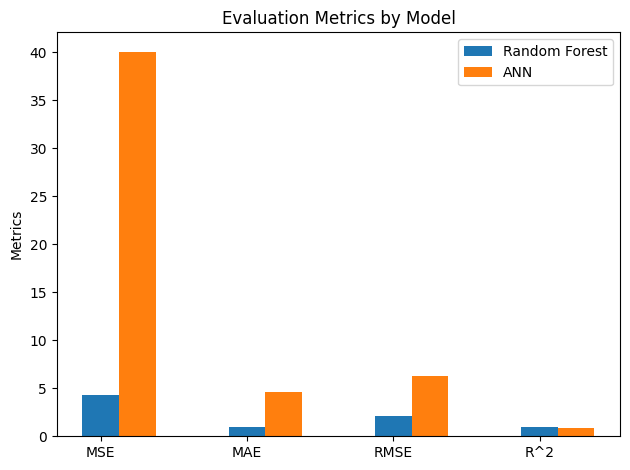

In [92]:
labels = ['MSE', 'MAE', 'RMSE', 'R^2']
rf_metrics = [rf_mse, rf_mae, rf_rmse, rf_r2]
ann_metrics = [ann_mse, ann_mae, ann_rmse, ann_r2]

x = np.arange(len(labels))
width = 0.25

fig, ax = plt.subplots()
rects1 = ax.bar(x, rf_metrics, width, label='Random Forest')
rects2 = ax.bar(x + width, ann_metrics, width, label='ANN')

ax.set_ylabel('Metrics')
ax.set_title('Evaluation Metrics by Model')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

fig.tight_layout()

plt.show()

print()

## **Hypertuning RFR and ANN**

Hypertuning is a method in which iterations test varying potential parameter values are evaluated in contrast with a specified cross validation score. Two varying approaches were taken to optimize the model and determine the optimal parameters, grid search and Bayesian Optimization.  Grid search optimization determines the optimal parameters by conducting an exhaustive search for the provided parameter conditions. This method evaluates each combination of hyperparameters and selects the one that maximizes the specified evaluation metric. This becomes computationally expensive as the size of the dataset and the numbers of parameter options increase. However, it ensures a thorough exploration of the hyperparameter space which provides the reasoning behind the high computational cost. In contrast, Bayesian optimization compares to gradient descent in that it takes all the parameters and goes in the direction of improving accuracy. Once all directions have been exhausted, the set of parameters with the most accurate predictions is chosen. The reasoning why these two optimization methods were used is due to their approaches when it came to tuning. Although both methods are capable of hyper tuning parameters, they do so with differing mathematical approaches. Through this, a rough analysis could be done to determine further optimization techniques with similar methodologies to the best technique. A comparison between the simple, grid search, and Bayesian tuned parameters was done to determine if accuracy could be retrieved. 

### **RFR Using Bayesian Optimization**

In [93]:
def plot_bias_variance(cv_scores):
    train_mse = -np.array(cv_scores['train_mse'])
    val_mse = -np.array(cv_scores['test_mse'])
    train_rmse = np.sqrt(train_mse)
    val_rmse = np.sqrt(val_mse)

    plt.figure(figsize=(10, 5))
    plt.plot(train_mse, label='Train MSE', marker='o')
    plt.plot(val_mse, label='Validation MSE', marker='s')
    plt.plot(train_rmse, label='Train RMSE', marker='^')
    plt.plot(val_rmse, label='Validation RMSE', marker='v')
    plt.title("Bias-Variance Tradeoff Across CV Folds (Random Forest - BO)")
    plt.xlabel("Fold")
    plt.ylabel("Error")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

def plot_rf_bo_iterations(Bayesian_search):
    target_values = [-res['target'] for res in Bayesian_search.res]  # Convert to MSE

    plt.figure(figsize=(8, 5))
    plt.plot(range(1, len(target_values) + 1), target_values, marker='o', color='teal')
    plt.title("Random Forest Bayesian Optimization - Target (MSE) Over Iterations")
    plt.xlabel("Iteration")
    plt.ylabel("Cross-Validated MSE")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# 🌲 Random Forest + Bayesian Optimization + Evaluation
def RF_model_BO(X_train, y_train, X_test, y_test):
    pipeline = Pipeline([
        ('data_processing', data_pipeline),  
        ('model', RandomForestRegressor(random_state=42))  
    ])

    def RF_model_objective(n_estimators, min_samples_split, min_samples_leaf):
        pipeline.set_params(
            model__n_estimators=int(n_estimators),
            model__min_samples_split=int(min_samples_split),
            model__min_samples_leaf=int(min_samples_leaf)
        )

        scores = cross_validate(
            pipeline,
            X_train,
            y_train,
            cv=5,
            scoring="neg_mean_squared_error", 
            n_jobs=-1
        )
        return np.mean(scores['test_score'])

    param_grid = {
        'n_estimators': (30, 200),
        'min_samples_split': (2, 8),
        'min_samples_leaf': (1, 8),
    }

    Bayesian_search = BayesianOptimization(
        f=RF_model_objective,
        pbounds=param_grid,
        random_state=42
    )
    Bayesian_search.maximize(init_points=5, n_iter=15)

    params = Bayesian_search.max['params']
    params['n_estimators'] = int(params['n_estimators'])
    params['min_samples_split'] = int(params['min_samples_split'])
    params['min_samples_leaf'] = int(params['min_samples_leaf'])

    print("\n✅ Best Hyperparameters:", params)

    pipeline.set_params(
        model__n_estimators=params['n_estimators'],
        model__min_samples_split=params['min_samples_split'],
        model__min_samples_leaf=params['min_samples_leaf']
    )

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    print("\n🔎 Evaluation Metrics:")
    print(f"MSE: {mse:.4f} | MAE: {mae:.4f}")
    print(f"RMSE: {rmse:.4f} | R^2: {r2:.4f}")

    cv_scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=5,
        scoring={
            'mse': make_scorer(mean_squared_error, greater_is_better=False),
            'mae': make_scorer(mean_absolute_error, greater_is_better=False),
            'r2': make_scorer(r2_score)
        },
        return_train_score=True,
        n_jobs=-1
    )

    train_mse = -np.mean(cv_scores['train_mse'])
    val_mse = -np.mean(cv_scores['test_mse'])
    train_rmse = np.mean(np.sqrt(-cv_scores['train_mse']))
    val_rmse = np.mean(np.sqrt(-cv_scores['test_mse']))
    train_mae = -np.mean(cv_scores['train_mae'])
    val_mae = -np.mean(cv_scores['test_mae'])
    train_r2 = np.mean(cv_scores['train_r2'])
    val_r2 = np.mean(cv_scores['test_r2'])

    print("\n📊 Cross-Validation Scores:")
    print(f'Train MSE: {train_mse:.4f} | RMSE: {train_rmse:.4f}')
    print(f'Validation MSE: {val_mse:.4f} | RMSE: {val_rmse:.4f}')
    print(f'Train MAE: {train_mae:.4f}')
    print(f'Validation MAE: {val_mae:.4f}')
    print(f'Train R^2: {train_r2:.4f}')
    print(f'Validation R^2: {val_r2:.4f}')

    plot_bias_variance(cv_scores)
    plot_rf_bo_iterations(Bayesian_search)
    
    return mse, mae, rmse, r2, cv_scores

|   iter    |  target   | min_sa... | min_sa... | n_esti... |
-------------------------------------------------------------
| 1         | -6.969    | 3.622     | 7.704     | 154.4     |
| 2         | -8.361    | 5.191     | 2.936     | 56.52     |
| 3         | -6.208    | 1.407     | 7.197     | 132.2     |
| 4         | -8.147    | 5.957     | 2.124     | 194.9     |
| 5         | -8.981    | 6.827     | 3.274     | 60.91     |
| 6         | -9.99     | 8.0       | 2.0       | 139.4     |
| 7         | -6.076    | 1.878     | 6.641     | 128.9     |
| 8         | -6.337    | 1.0       | 8.0       | 121.2     |
| 9         | -10.0     | 8.0       | 2.0       | 118.4     |
| 10        | -6.2      | 1.591     | 7.644     | 163.4     |
| 11        | -10.0     | 8.0       | 2.446     | 163.9     |
| 12        | -5.755    | 1.0       | 2.0       | 130.1     |
| 13        | -5.799    | 1.277     | 3.056     | 124.3     |
| 14        | -6.324    | 1.0       | 8.0       | 171.9     |
| 15    

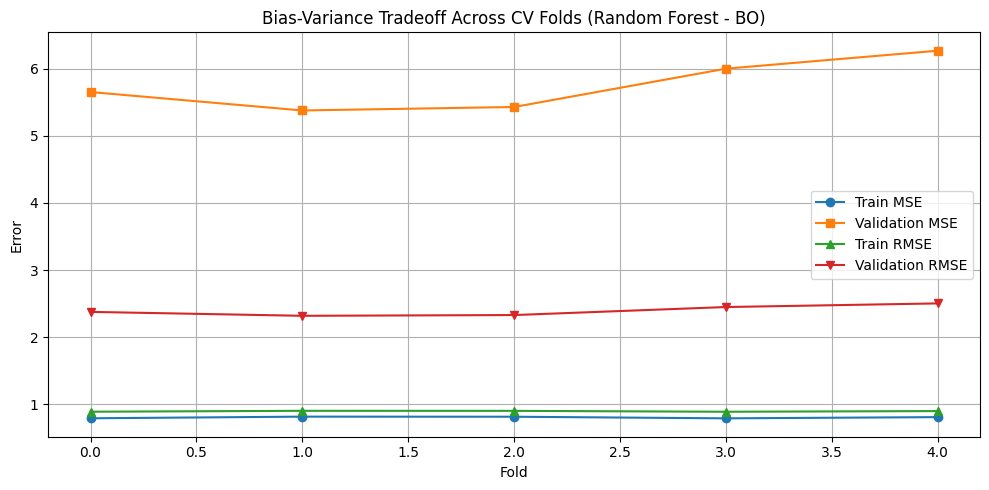

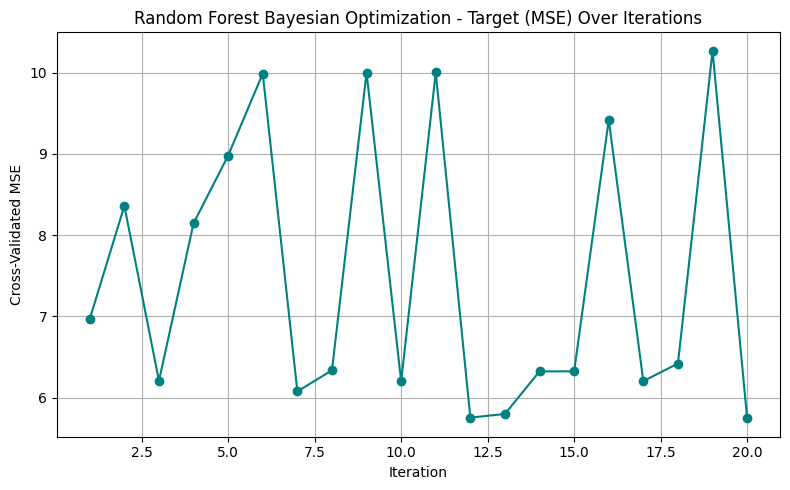

Random Forest Metrics:
MSE: 4.2594
MAE: 0.9910
RMSE: 2.0638
R^2: 0.9881
{'fit_time': array([67.19849563, 67.51763678, 67.09524584, 66.92886972, 67.43268275]), 'score_time': array([0.39098477, 0.41646051, 0.40323997, 0.38438773, 0.40809226]), 'test_mse': array([-5.65219436, -5.3778238 , -5.42949047, -6.00026126, -6.26786538]), 'train_mse': array([-0.7923947 , -0.81676039, -0.81557353, -0.79153837, -0.80958311]), 'test_mae': array([-1.17665225, -1.15598987, -1.16160569, -1.18881954, -1.21814457]), 'train_mae': array([-0.43742807, -0.44190525, -0.44132451, -0.43795878, -0.43878424]), 'test_r2': array([0.98423485, 0.98514819, 0.98502554, 0.98318586, 0.98268441]), 'train_r2': array([0.99780428, 0.99773131, 0.99773382, 0.99780934, 0.99775142])}


In [94]:
rfBO_mse, rfBO_mae, rfBO_rmse, rfBO_r2, BO_cv_scores = RF_model_BO(X_train, y_train, X_test, y_test)
print("Random Forest Metrics:")
print(f'MSE: {rfBO_mse:.4f}')
print(f'MAE: {rfBO_mae:.4f}')
print(f'RMSE: {rfBO_rmse:.4f}')
print(f'R^2: {rfBO_r2:.4f}')
print(BO_cv_scores)

### **RFR Using Gridsearch**

In [95]:
def plot_bias_variance(cv_scores):
    train_mse = -np.array(cv_scores['train_mse'])
    val_mse = -np.array(cv_scores['test_mse'])
    train_rmse = np.sqrt(train_mse)
    val_rmse = np.sqrt(val_mse)

    plt.figure(figsize=(10, 5))
    plt.plot(train_mse, label='Train MSE', marker='o')
    plt.plot(val_mse, label='Validation MSE', marker='s')
    plt.plot(train_rmse, label='Train RMSE', marker='^')
    plt.plot(val_rmse, label='Validation RMSE', marker='v')
    plt.title("Bias-Variance Tradeoff Across CV Folds (Random Forest)")
    plt.xlabel("Fold")
    plt.ylabel("Error")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

def plot_rf_gridsearch_iterations(grid_search):
    # Extract mean test scores and convert them to MSE (they're negative)
    mean_scores = -grid_search.cv_results_['mean_test_score']

    plt.figure(figsize=(8, 5))
    plt.plot(range(1, len(mean_scores)+1), mean_scores, marker='o')
    plt.title("Random Forest Grid Search - Target (MSE) Over Iterations")
    plt.xlabel("Iteration")
    plt.ylabel("Mean CV MSE")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


# 🌲 Random Forest Grid Search + Evaluation
def RF_modelGS(X_train, y_train, X_test, y_test):
    pipeline = Pipeline([
        ('data_processing', data_pipeline),  
        ('model', RandomForestRegressor(random_state=42)) 
    ])

    param_grid = {
        'model__n_estimators': [50, 100, 200, 300],
        'model__min_samples_split': [2, 5, 10],
        'model__min_samples_leaf': [1, 2, 4, 10]
    }

    cv = 5
    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        cv=cv,
        scoring='neg_mean_squared_error',
        n_jobs=-1
    )
    grid_search.fit(X_train, y_train)

    best_params = grid_search.best_params_
    print("\n✅ Best Hyperparameters:", best_params)

    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    print("\n🔎 Test Set Evaluation Metrics:")
    print(f'MSE: {mse:.4f} | MAE: {mae:.4f}')
    print(f'RMSE: {rmse:.4f} | R^2: {r2:.4f}')

    cv_scores = cross_validate(
        best_model,
        X_train,
        y_train,
        cv=cv,
        scoring={
            'mse': make_scorer(mean_squared_error, greater_is_better=False),
            'mae': make_scorer(mean_absolute_error, greater_is_better=False),
            'r2': make_scorer(r2_score)
        },
        return_train_score=True,
        n_jobs=-1
    )

    train_mse = -np.mean(cv_scores['train_mse'])
    val_mse = -np.mean(cv_scores['test_mse'])
    train_rmse = np.mean(np.sqrt(-cv_scores['train_mse']))
    val_rmse = np.mean(np.sqrt(-cv_scores['test_mse']))
    train_mae = -np.mean(cv_scores['train_mae'])
    val_mae = -np.mean(cv_scores['test_mae'])
    train_r2 = np.mean(cv_scores['train_r2'])
    val_r2 = np.mean(cv_scores['test_r2'])

    print("\n📊 Cross-Validation Scores:")
    print(f'Train MSE: {train_mse:.4f} | RMSE: {train_rmse:.4f}')
    print(f'Validation MSE: {val_mse:.4f} | RMSE: {val_rmse:.4f}')
    print(f'Train MAE: {train_mae:.4f}')
    print(f'Validation MAE: {val_mae:.4f}')
    print(f'Train R^2: {train_r2:.4f}')
    print(f'Validation R^2: {val_r2:.4f}')

    plot_bias_variance(cv_scores)
    plot_rf_gridsearch_iterations(grid_search)
    
    return mse, mae, rmse, r2


✅ Best Hyperparameters: {'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 300}

🔎 Test Set Evaluation Metrics:
MSE: 4.2589 | MAE: 0.9907
RMSE: 2.0637 | R^2: 0.9881

📊 Cross-Validation Scores:
Train MSE: 0.7910 | RMSE: 0.8894
Validation MSE: 5.7353 | RMSE: 2.3938
Train MAE: 0.4363
Validation MAE: 1.1780
Train R^2: 0.9978
Validation R^2: 0.9841


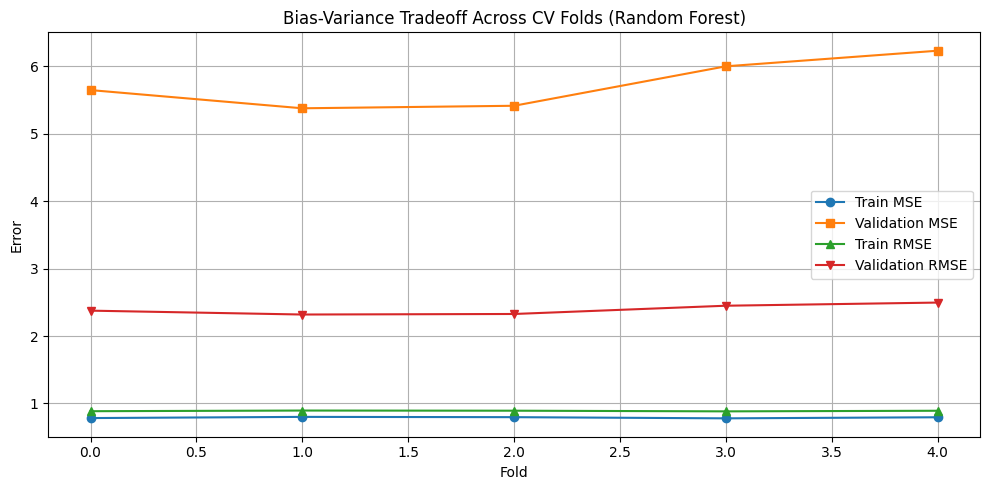

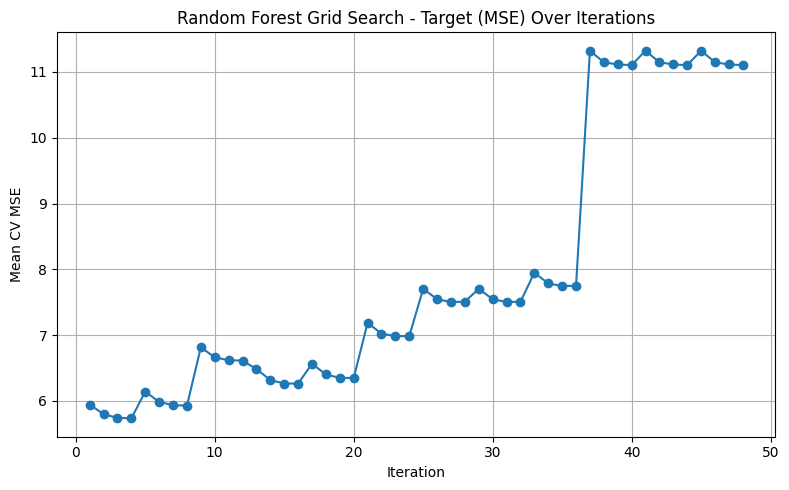

Random Forest Metrics:
MSE: 4.2589
MAE: 0.9907
RMSE: 2.0637
R^2: 0.9881


In [96]:
# Example usage
rfGS_mse, rfGS_mae, rfGS_rmse, rfGS_r2 = RF_modelGS(X_train, y_train, X_test, y_test)
print("Random Forest Metrics:")
print(f'MSE: {rfGS_mse:.4f}')
print(f'MAE: {rfGS_mae:.4f}')
print(f'RMSE: {rfGS_rmse:.4f}')
print(f'R^2: {rfGS_r2:.4f}')

**Train and Validation Results**
| Method     | Train MSE | Validation MSE | Train MAE | Validation MAE | Train R^2 | Validation R^2 |
|------------|-----------|----------------|-----------|----------------|-----------|----------------|
| Vanilla    | 0.8210    | 5.8129         | 0.4452    | 1.1887         | 0.9977    | 0.9839         | 
| Bayesian   | 0.8052    | 5.7455         | 0.4395    | 1.1802         | 0.9978    | 0.9841         |
| Gridsearch | 0.7910    | 5.7353         | 0.4363    | 1.1780         | 0.9978    | 0.9841         | 

**Test Results**
| Method     | Test MSE | Test MAE | Test RMSE | Test R^2 |
|------------|----------|----------|-----------|----------|
| Vanilla    | 4.33997  | 1.0009   | 2.0832    | 0.9878   |  
| Bayesian   | 4.2594   | 0.9910   | 2.0638    | 0.9881   | 
| Gridsearch | 4.2589   | 0.9907   | 2.0637    | 0.9881   | 

**Training & Validation Performance**
- All three models achieved exceptionally high $R^2$ scores on the training set and validation set, suggesting strong fit and generalization
- Validation MSE and MAE show marginal improvement from Vanilla to Bayesian and Grid Search:
  - Validation MAE decreased from 1.1887 (Vanilla) to 1.802 (Bayesian) and 1.1780 (Grid Search)
  - Validation MSE reduced from 5.8129 (Vanilla) to 5.7455 (Bayesian) and 5.7353 (Grid Search)
- Differences between methods are numerically small but consistent, with Grid Search slightly outperforming others in minimizing error metrics

**Test Performance**
- All methods generalize well indicating excellent predictive performance on unseen data.
- Test MAE and RMSE are very close across methods:
  - Test MAE is lowest for Grid Search (0.9907) and Bayesian Optimization (0.9910), outperforming Vanilla (1.0009).
  - Test RMSE shows similar patterns with Grid Search slightly ahead.

**Hyper Parameter Comparison**

| Method     | Min_Samp_Leaf | Min_Samp_Split | #_Estimat | 
|------------|---------------|----------------|-----------|
| Vanilla    | 1             | 2              | 100       |  
| Bayesian   | 1             | 2              | 183       |
| Gridsearch | 1             | 2              | 300       |

- All models converged on the same values for `min_samples_leaf` and `min_samples_split`, suggesting that deeper trees are optimal for this task.
- The number of estimators is the primary differentiating hyperparameter:
  - Performance improves with increasing number of trees, confirming the benefit of ensemble size on error reduction.
  - However computational cost increases with more trees, making Bayesian Optimization a favorable trade-off in practice.

**Conclusion**
- Grid Search delivers the best test performance, but by a narrow margin.
- Bayesian Optimization is competitive, offering similar performance with potentially fewer evaluations depending on the search space.




### **ANN Using Bayesian Optimization**

In [97]:
activationL = ['swish', 'relu', 'selu']

class KerasWrapper(BaseEstimator, RegressorMixin):
    def __init__(self, build_fn=None, epochs=100, batch_size=32, verbose=0):
        self.build_fn = build_fn
        self.epochs = epochs
        self.batch_size = batch_size
        self.verbose = verbose
        self.model_ = None

    def fit(self, X_train, y_train):
        self.model_ = self.build_fn()
        if not hasattr(self.model_, 'optimizer'):
            self.model_.compile(optimizer='adam', loss='mean_squared_error')

        es = EarlyStopping(
            monitor='val_loss', 
            patience=20, 
            restore_best_weights=True,
            verbose=0
        )
        self.model_.fit(
            X_train, y_train,
            validation_split=0.2,
            epochs=self.epochs,
            batch_size=self.batch_size,
            verbose=self.verbose,
            callbacks=[es]
        )
        return self

    def predict(self, X_train):
        check_is_fitted(self)
        return self.model_.predict(X_train).flatten()

    def __sklearn_is_fitted__(self):
        return hasattr(self, "model_") and self.model_ is not None

# Visualization function for Bayesian Optimization
def plot_bo_results(optimizer, param_names):
    iterations = range(1, len(optimizer.res) + 1)
    target_scores = [res['target'] for res in optimizer.res]

    plt.figure(figsize=(10, 5))
    plt.plot(iterations, target_scores, marker='o', linestyle='-', color='blue')
    plt.title("Bayesian Optimization - Target Over Iterations")
    plt.xlabel("Iteration")
    plt.ylabel("Negative MSE (higher is better)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Bias-Variance Tradeoff Plot
def plot_bias_variance(cv_scores):
    train_mse = -np.array(cv_scores['train_mse'])
    val_mse = -np.array(cv_scores['test_mse'])
    train_rmse = np.sqrt(train_mse)
    val_rmse = np.sqrt(val_mse)

    plt.figure(figsize=(10, 5))
    plt.plot(train_mse, label='Train MSE', marker='o')
    plt.plot(val_mse, label='Validation MSE', marker='s')
    plt.plot(train_rmse, label='Train RMSE', marker='^')
    plt.plot(val_rmse, label='Validation RMSE', marker='v')
    plt.title("Bias-Variance Tradeoff Across CV Folds")
    plt.xlabel("Fold")
    plt.ylabel("Error")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Main function
def ANN_modelBO(X_train, y_train, X_test, y_test, data_pipeline):
    def create_dummy_model():
        model = Sequential([layers.Dense(1, input_shape=(X_train.shape[1],))])
        model.compile(optimizer='adam', loss='mean_squared_error')
        return model

    model_pipeline = Pipeline([
        ('data_processing', data_pipeline),
        ('model', KerasWrapper(build_fn=create_dummy_model, epochs=1))
    ])

    params_ann_model = {
        'neurons': (8, 20),
        'activation': (0, len(activationL)-1),
        'learning_rate': (0.001, 0.1),
        'batch_size': (32, 128),
        'epochs': (50, 100)
    }

    def nn_cl_bo(neurons, activation, learning_rate, batch_size, epochs):
        neurons = int(neurons)
        activation = activationL[round(activation)]
        batch_size = int(batch_size)
        epochs = int(epochs)

        def create_model():
            model = Sequential([
                layers.Dense(neurons, activation=activation, input_shape=(X_train.shape[1],)),
                layers.Dense(neurons, activation=activation),
                layers.Dense(1)
            ])
            model.compile(
                optimizer=Adam(learning_rate=learning_rate),
                loss='mean_squared_error'
            )
            return model

        current_pipeline = Pipeline([
            ('data_processing', data_pipeline),
            ('model', KerasWrapper(
                build_fn=create_model,
                epochs=epochs,
                batch_size=batch_size,
                verbose=0
            ))
        ])

        scores = cross_validate(
            current_pipeline,
            X_train,
            y_train,
            scoring='neg_mean_squared_error',
            cv=5,
            error_score='raise'
        )
        return np.mean(scores['test_score'])

    ann_bo = BayesianOptimization(
        f=nn_cl_bo,
        pbounds=params_ann_model,
        random_state=42
    )
    ann_bo.maximize(init_points=5, n_iter=15)

    plot_bo_results(ann_bo, ['neurons', 'activation', 'learning_rate', 'batch_size', 'epochs'])

    params_nn_ = ann_bo.max['params']
    params_nn_['activation'] = activationL[round(params_nn_['activation'])]
    params_nn_['batch_size'] = int(params_nn_['batch_size'])
    params_nn_['neurons'] = int(params_nn_['neurons'])
    params_nn_['epochs'] = int(params_nn_['epochs'])

    def final_model_fn():
        model = Sequential([
            layers.Dense(params_nn_['neurons'], activation=params_nn_['activation'], 
                        input_shape=(X_train.shape[1],)),
            layers.Dense(params_nn_['neurons'], activation=params_nn_['activation']),
            layers.Dense(1)
        ])
        model.compile(
            optimizer=Adam(learning_rate=params_nn_['learning_rate']),
            loss='mean_squared_error'
        )
        return model

    final_pipeline = Pipeline([
        ('data_processing', data_pipeline),
        ('model', KerasWrapper(
            build_fn=final_model_fn,
            epochs=params_nn_['epochs'],
            batch_size=params_nn_['batch_size'],
            verbose=0
        ))
    ])

    final_pipeline.fit(X_train, y_train)
    y_pred = final_pipeline.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    cv_scores = cross_validate(
        final_pipeline,
        X_train,
        y_train,
        cv=5,
        scoring={
            'mse': make_scorer(mean_squared_error, greater_is_better=False),
            'mae': make_scorer(mean_absolute_error, greater_is_better=False),
            'r2': make_scorer(r2_score)
        },
        return_train_score=True,
        n_jobs=-1
    )

    train_mse = -np.mean(cv_scores['train_mse'])
    val_mse = -np.mean(cv_scores['test_mse'])
    train_rmse = np.mean(np.sqrt(-cv_scores['train_mse']))
    val_rmse = np.mean(np.sqrt(-cv_scores['test_mse']))
    train_mae = -np.mean(cv_scores['train_mae'])
    val_mae = -np.mean(cv_scores['test_mae'])
    train_r2 = np.mean(cv_scores['train_r2'])
    val_r2 = np.mean(cv_scores['test_r2'])

    print("\nCross-Validation Scores:")
    print(f'Train MSE: {train_mse:.4f} | RMSE: {train_rmse:.4f}')
    print(f'Validation MSE: {val_mse:.4f} | RMSE: {val_rmse:.4f}')
    print(f'Train MAE: {train_mae:.4f}')
    print(f'Validation MAE: {val_mae:.4f}')
    print(f'Train R^2: {train_r2:.4f}')
    print(f'Validation R^2: {val_r2:.4f}')

    print("\n🔎 Final Evaluation:")
    print(f"MSE: {mse:.4f} | MAE: {mae:.4f}")
    print(f"RMSE: {rmse:.4f} | R²: {r2:.4f}")
    print("\n✅ Best Hyperparameters:", params_nn_)

    plot_bias_variance(cv_scores)

    return mse, mae, rmse, r2, params_nn_, final_pipeline

|   iter    |  target   | activa... | batch_... |  epochs   | learni... |  neurons  |
-------------------------------------------------------------------------------------


c:\Users\ahmad\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


292/292 ━━━━━━━━━━━━━━━━━━━━ 0s 624us/step


c:\Users\ahmad\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


292/292 ━━━━━━━━━━━━━━━━━━━━ 0s 626us/step


...

292/292 ━━━━━━━━━━━━━━━━━━━━ 0s 606us/step


c:\Users\ahmad\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


292/292 ━━━━━━━━━━━━━━━━━━━━ 0s 633us/step


c:\Users\ahmad\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


292/292 ━━━━━━━━━━━━━━━━━━━━ 0s 649us/step
| 20        | -36.05    | 1.728     | 86.92     | 70.81     | 0.01914   | 11.38     |


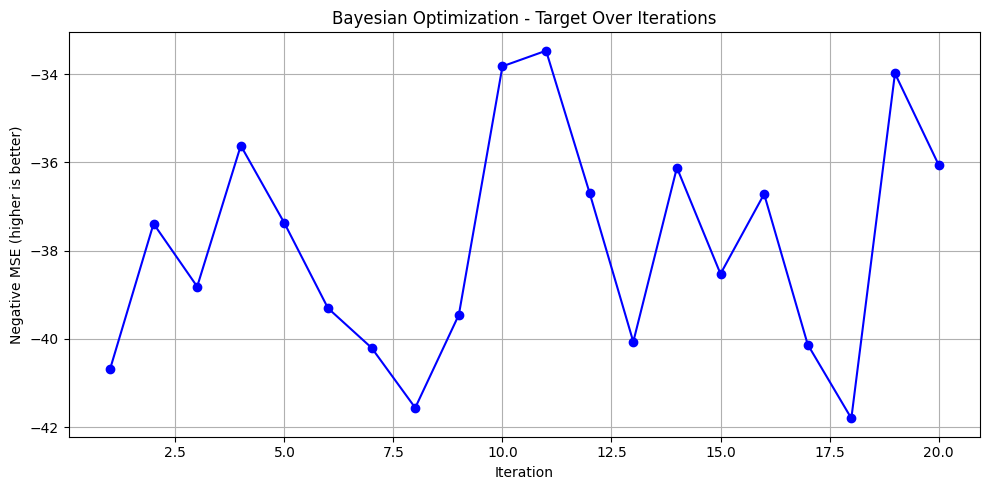

c:\Users\ahmad\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


624/624 ━━━━━━━━━━━━━━━━━━━━ 0s 730us/step

Cross-Validation Scores:
Train MSE: 31.0649 | RMSE: 5.5717
Validation MSE: 32.0391 | RMSE: 5.6577
Train MAE: 4.0126
Validation MAE: 4.0645
Train R^2: 0.9138
Validation R^2: 0.9111

🔎 Final Evaluation:
MSE: 32.7780 | MAE: 4.0950
RMSE: 5.7252 | R²: 0.9081

✅ Best Hyperparameters: {'activation': 'swish', 'batch_size': 37, 'epochs': 93, 'learning_rate': np.float64(0.021884075910131376), 'neurons': 15}


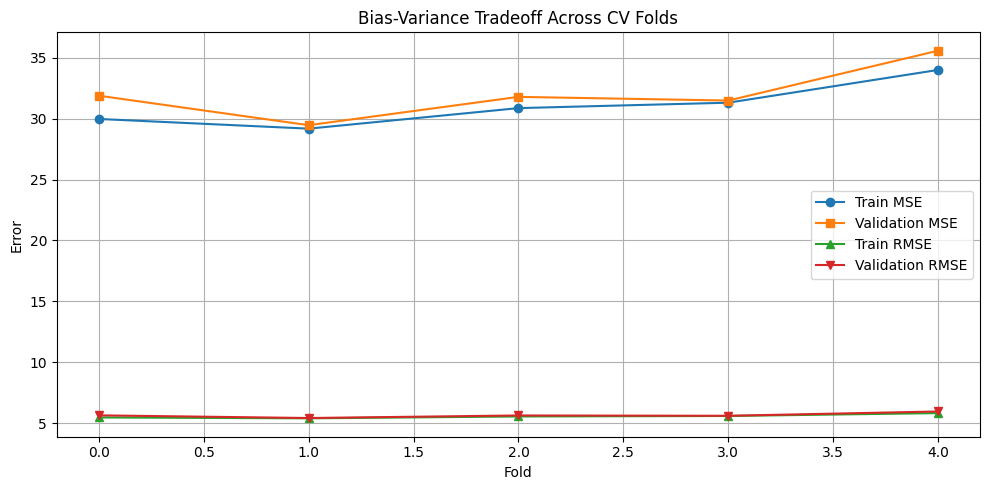


ANN Metrics:
MSE: 32.7780
MAE: 4.0950
RMSE: 5.7252
R²: 0.9081

✅ Best Hyperparameters: {'activation': 'swish', 'batch_size': 37, 'epochs': 93, 'learning_rate': np.float64(0.021884075910131376), 'neurons': 15}
Pipeline(steps=[('data_processing',
                 Pipeline(steps=[('scaler', StandardScaler())])),
                ('model',
                 KerasWrapper(batch_size=37,
                              build_fn=<function ANN_modelBO.<locals>.final_model_fn at 0x0000018775D1F880>,
                              epochs=93))])


In [ ]:
annBO_mse, annBO_mae, annBO_rmse, annBO_r2, params_nn_, final_pipeline = ANN_modelBO(X_train, y_train, X_test, y_test, data_pipeline)

print("\nANN Metrics:")
print(f"MSE: {annBO_mse:.4f}")
print(f"MAE: {annBO_mae:.4f}")
print(f"RMSE: {annBO_rmse:.4f}")
print(f"R²: {annBO_r2:.4f}")
print("\n✅ Best Hyperparameters:", params_nn_)
print(final_pipeline)

### **ANN Using Gridsearch**

In [99]:
class KerasWrapper(BaseEstimator, RegressorMixin):
    def __init__(self, build_fn, epochs=100, batch_size=32, verbose=0):
        self.build_fn = build_fn
        self.epochs = epochs
        self.batch_size = batch_size
        self.verbose = verbose
        self.model = None

    def fit(self, X, y):
        self.model = self.build_fn()
        es = EarlyStopping(
            monitor='val_loss', 
            patience=20, 
            restore_best_weights=True,
            verbose=0
        )
        self.model.fit(
            X, y,
            validation_split=0.2,
            epochs=self.epochs,
            batch_size=self.batch_size,
            verbose=self.verbose,
            callbacks=[es]
        )
        return self

    def predict(self, X):
        return self.model.predict(X).flatten()

activationL = ['relu', 'selu', 'swish']

def ANN_modelGS(X_train, y_train, X_test, y_test):
    model_pipeline = Pipeline([
        ('data_processing', data_pipeline)
    ])
    
    X_train = model_pipeline.fit_transform(X_train)
    X_test = model_pipeline.transform(X_test)

    param_grid = {
        'neurons': [8, 16, 32],               
        'activation': activationL,
        'learning_rate': [0.005, 0.1],
        'batch_size': [32, 64],
        'epochs': [50, 100]                         
    }

    def build_model(neurons=16, activation='relu', learning_rate=0.001):
        def model_fn():
            model = Sequential([
                layers.Dense(
                    neurons, 
                    input_dim=X_train.shape[1], 
                    activation=activation,
                ),
                layers.Dense(
                    neurons, 
                    activation=activation,
                ),
                layers.Dense(1)
            ])
            opt = Adam(
                learning_rate=learning_rate,
            )
            model.compile(
                loss='mean_squared_error', 
                optimizer=opt
            )
            return model
        return model_fn

    best_score = -np.inf
    best_params = None
    scores_over_time = []

    print("Starting Grid Search with {} combinations...".format(
        len(param_grid['neurons']) * 
        len(param_grid['activation']) * 
        len(param_grid['learning_rate']) * 
        len(param_grid['batch_size']) *
        len(param_grid['epochs'])
    ))

    for neurons in param_grid['neurons']:
        for activation in param_grid['activation']:
            for lr in param_grid['learning_rate']:
                for bs in param_grid['batch_size']:
                    for ep in param_grid['epochs']:

                        current_params = {
                            'neurons': neurons,
                            'activation': activation,
                            'learning_rate': lr,
                            'batch_size': bs,
                            'epochs': ep
                        }

                        print(f"\nTesting: {current_params}")

                        model = KerasWrapper(
                            build_fn=build_model(neurons, activation, lr),
                            epochs=ep,
                            batch_size=bs,
                            verbose=0
                        )

                        try:
                            scores = cross_validate(
                                model,
                                X_train,
                                y_train,
                                scoring='neg_mean_squared_error',
                                cv=5,
                                n_jobs=-1,
                                error_score='raise'
                            )
                            mean_score = np.mean(scores['test_score'])
                            print(f"Score: {mean_score:.4f}")
                            scores_over_time.append(mean_score)

                            if mean_score > best_score:
                                best_score = mean_score
                                best_params = current_params
                                print("🔥 New best!")

                        except Exception as e:
                            print(f"❌ Failed with: {str(e)}")
                            continue

    print("\n✅ Best Hyperparameters:", best_params)

    final_model = KerasWrapper(
        build_fn=build_model(
            neurons=best_params['neurons'],
            activation=best_params['activation'],
            learning_rate=best_params['learning_rate']
        ),
        epochs=100,  
        batch_size=best_params['batch_size'],
        verbose=1
    )

    print("\nTraining final model...")
    final_model.fit(X_train, y_train)

    y_pred = final_model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    print("\n🔎 Final Evaluation:")
    print(f"MSE: {mse:.4f} | MAE: {mae:.4f}")
    print(f"RMSE: {rmse:.4f} | R²: {r2:.4f}")

    # Cross-Validation for train vs validation
    cv_scores = cross_validate(
        final_model,
        X_train,
        y_train,
        scoring={
            'mse': make_scorer(mean_squared_error, greater_is_better=False),
            'mae': make_scorer(mean_absolute_error, greater_is_better=False),
            'r2': make_scorer(r2_score)
        },
        cv=5,
        return_train_score=True,
        n_jobs=-1
    )

    train_mse = -np.mean(cv_scores['train_mse'])
    val_mse = -np.mean(cv_scores['test_mse'])
    train_mae = -np.mean(cv_scores['train_mae'])
    val_mae = -np.mean(cv_scores['test_mae'])
    train_r2 = np.mean(cv_scores['train_r2'])
    val_r2 = np.mean(cv_scores['test_r2'])
    train_rmse = np.sqrt(train_mse)
    val_rmse = np.sqrt(val_mse)

    print("\nCross-Validation Scores:")
    print(f'Train MSE: {train_mse:.4f} | Validation MSE: {val_mse:.4f}')
    print(f'Train MAE: {train_mae:.4f} | Validation MAE: {val_mae:.4f}')
    print(f'Train RMSE: {train_rmse:.4f} | Validation RMSE: {val_rmse:.4f}')
    print(f'Train R^2: {train_r2:.4f} | Validation R^2: {val_r2:.4f}')

    # Plot: Target over iterations
    plt.figure(figsize=(10, 5))
    plt.plot(range(1, len(scores_over_time) + 1), scores_over_time, marker='o')
    plt.title('Target (Neg MSE) over Grid Search Iterations')
    plt.xlabel('Iteration')
    plt.ylabel('Mean CV Neg MSE')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Plot: Bias-Variance tradeoff - Line Plot by Fold
    def plot_bias_variance(cv_scores):
        train_mse = -np.array(cv_scores['train_mse'])
        val_mse = -np.array(cv_scores['test_mse'])
        train_rmse = np.sqrt(train_mse)
        val_rmse = np.sqrt(val_mse)

        plt.figure(figsize=(10, 5))
        plt.plot(train_mse, label='Train MSE', marker='o')
        plt.plot(val_mse, label='Validation MSE', marker='s')
        plt.plot(train_rmse, label='Train RMSE', marker='^')
        plt.plot(val_rmse, label='Validation RMSE', marker='v')
        plt.title("Bias-Variance Tradeoff Across CV Folds")
        plt.xlabel("Fold")
        plt.ylabel("Error")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    plot_bias_variance(cv_scores)

    return mse, mae, rmse, r2, best_params



Starting Grid Search with 72 combinations...

Testing: {'neurons': 8, 'activation': 'relu', 'learning_rate': 0.005, 'batch_size': 32, 'epochs': 50}
Score: -47.6679
🔥 New best!

Testing: {'neurons': 8, 'activation': 'relu', 'learning_rate': 0.005, 'batch_size': 32, 'epochs': 100}
Score: -45.9121
🔥 New best!

Testing: {'neurons': 8, 'activation': 'relu', 'learning_rate': 0.005, 'batch_size': 64, 'epochs': 50}
Score: -46.3139

Testing: {'neurons': 8, 'activation': 'relu', 'learning_rate': 0.005, 'batch_size': 64, 'epochs': 100}
Score: -44.4164
🔥 New best!

Testing: {'neurons': 8, 'activation': 'relu', 'learning_rate': 0.1, 'batch_size': 32, 'epochs': 50}
Score: -45.4088

Testing: {'neurons': 8, 'activation': 'relu', 'learning_rate': 0.1, 'batch_size': 32, 'epochs': 100}
Score: -45.6076

Testing: {'neurons': 8, 'activation': 'relu', 'learning_rate': 0.1, 'batch_size': 64, 'epochs': 50}
Score: -44.3268
🔥 New best!

Testing: {'neurons': 8, 'activation': 'relu', 'learning_rate': 0.1, 'batch_s

c:\Users\ahmad\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
1165/1165 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 615.6885 - val_loss: 52.1968
Epoch 2/100
1165/1165 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 49.4410 - val_loss: 51.0458
Epoch 3/100
1165/1165 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 48.5221 - val_loss: 48.2951
Epoch 4/100
1165/1165 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 45.6905 - val_loss: 47.2483
Epoch 5/100
1165/1165 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 44.4102 - val_loss: 45.0234
Epoch 6/100
1165/1165 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 42.7575 - val_loss: 42.9710
Epoch 7/100
1165/1165 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 41.8724 - val_loss: 44.6057
Epoch 8/100
1165/1165 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 39.7899 - val_loss: 39.9858
Epoch 9/100
1165/1165 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 38.5045 - val_loss: 42.3062
Epoch 10/100
1165/1165 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 37.4116 - val_loss: 39.8907
Epoch 11/100
1165/1165 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 36.4842 - val_loss: 37.8

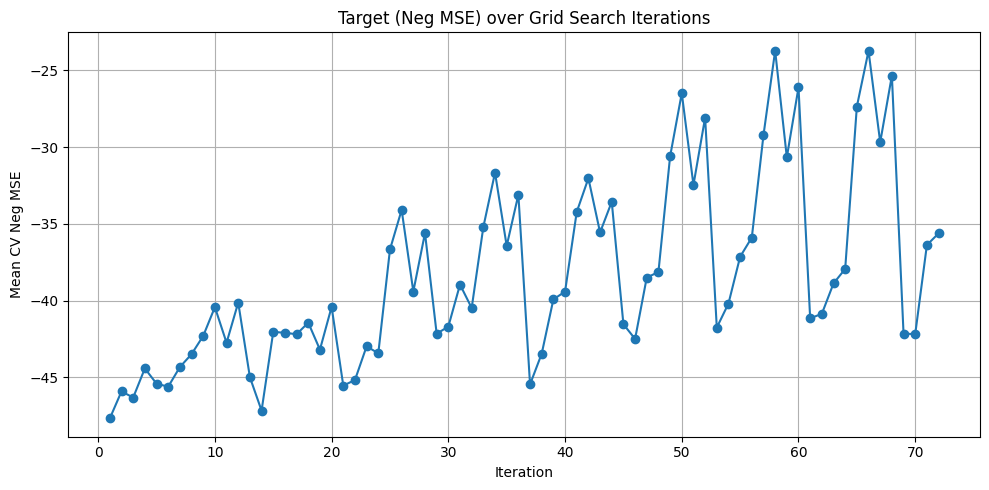

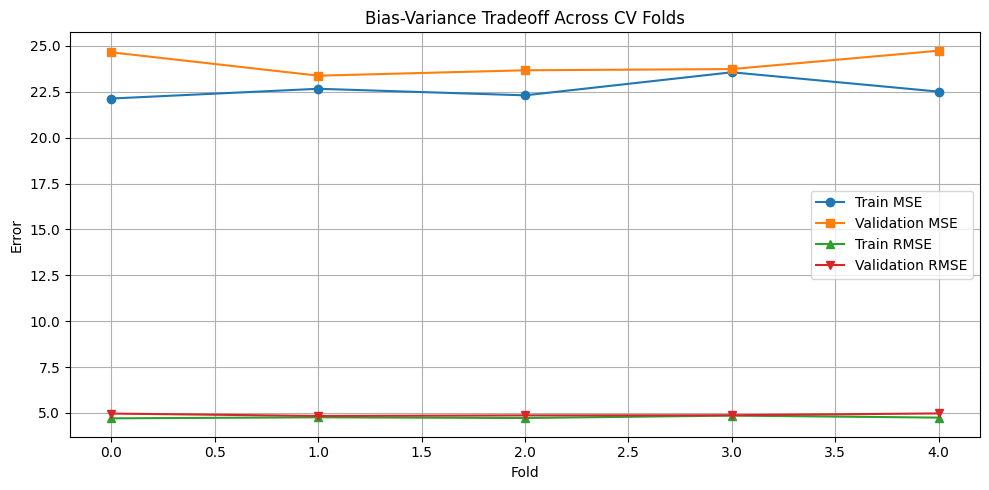

ANN Metrics:
MSE: 21.6122
MAE: 3.2604
RMSE: 4.6489
R^2: 0.9394

✅ Best Hyperparameters: {'neurons': 32, 'activation': 'selu', 'learning_rate': 0.005, 'batch_size': 32, 'epochs': 100}


In [100]:
annGS_mse, annGS_mae, annGS_rmse, annGS_r2, best_params = ANN_modelGS(X_train, y_train, X_test, y_test)
print("ANN Metrics:")
print(f'MSE: {annGS_mse:.4f}')
print(f'MAE: {annGS_mae:.4f}')
print(f'RMSE: {annGS_rmse:.4f}')
print(f'R^2: {annGS_r2:.4f}')
print("\n✅ Best Hyperparameters:", best_params)

**Training and Validation Results**

| Method     | Train MSE | Validation MSE | Train MAE | Validation MAE | Train R^2 | Validation R^2 |
|------------|-----------|----------------|-----------|----------------|-----------|----------------|
| Vanilla    | 43.990    | 44.0062        | 4.8046    | 4.8089         | 0.8779    | 0.8777         |
| Bayesian   | 31.065    | 32.0291        | 4.0126    | 4.0645         | 0.9138    | 0.9111         |
| Gridsearch | 22.635    | 24.035         | 3.3534    | 3.3496         | 0.9372    | 0.9333         |

- Training and validation performance improved progressively from Vanilla to Bayesian to Grid Search:
  - Grid Search achieved the lowest validation MAE (3.35) and highest validation R² (0.9333)
  - Bayesian Optimization yielded intermediate performance, outperforming Vanilla but not quite matching Grid Search
  - The Vanilla model had notably higher errors, indicating that the default ANN configuration was suboptimal
- Grid Search shows a strong balance between bias and variance, reflected by its low error metrics and high explanatory power across both training and validation sets

**Test Results**

| Method     | Test MSE | Test MAE | Test RMSE | Test R^2 |
|------------|----------|----------|-----------|----------|
| Vanilla    | 40.0814  | 4.5746   | 6.3310    | 0.8876   |
| Bayesian   | 32.7780  | 4.0950   | 5.7252    | 0.9081   |
| Gridsearch | 21.6122  | 3.2604   | 4.6489    | 0.9394   |

- The Grid Search model significantly outperformed other configurations:
  - Lowest Test MSE (21.61), MAE (3.26), and RMSE (4.65)
  - Highest Test R² (0.9394), indicating excellent generalization
- Bayesian Optimization also improved performance over Vanilla:
  - Reduced MAE from 4.57 (Vanilla) to 4.10, and R² increased from 0.8876 to 0.9081
- These improvements validate the effectiveness of data-driven hyperparameter tuning for ANN performance enhancement

**Hyperparameter Comparison**

| Method     | Activ_Fun | Neur_Lay_1 | Neur_Lay_2   | Learn_Rate | Batch_Size | epochs |
|------------|-----------|------------|--------------|------------|------------|--------|
| Vanilla    | relu      | 10         | 8            | 0.001      | 32         | 100    |
| Bayesian   | swish     | 15         | 15           | 0.02188    | 37         | 93     |
| Gridsearch | selu      | 32         | 32           | 0.005      | 32         | 100    |

- Activation functions influenced learning efficiency and non-linearity handling:
  - `selu` (self-normalizing) in Grid Search provided the best results, while `swish` (Bayesian) also outperformed `relu` (Vanilla)
- Network depth and width had a substantial impact:
  - Grid Search used the widest and deepest architecture (32x2)
- Learning rate optimization was key:
  - The Bayesian-optimized learning rate (0.02188) is substantially higher than the others, showing that the model could learn faster without diverging
- Epochs and batch sizes were relatively consistent, indicating that architectural and learning rate tuning had a larger impact

### **Comparison of Bayesian Optimization Between RFR and ANN**

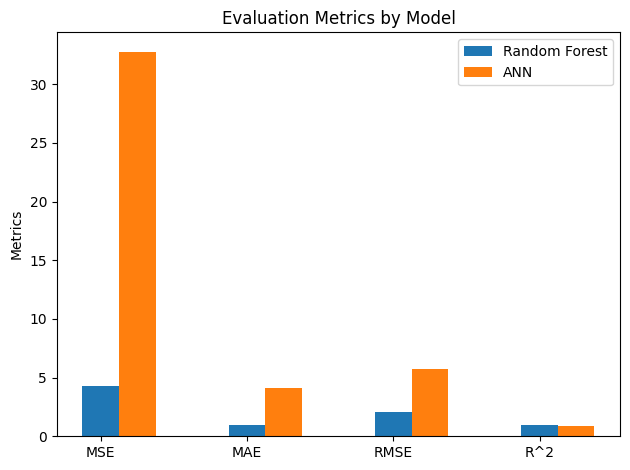

In [101]:
labels = ['MSE', 'MAE', 'RMSE', 'R^2']
rfBO_metrics = [rfBO_mse, rfBO_mae, rfBO_rmse, rfBO_r2]
annBO_metrics = [annBO_mse, annBO_mae, annBO_rmse, annBO_r2]

x = np.arange(len(labels))
width = 0.25

fig, ax = plt.subplots()
rects1 = ax.bar(x, rfBO_metrics, width, label='Random Forest')
rects2 = ax.bar(x + width, annBO_metrics, width, label='ANN')

ax.set_ylabel('Metrics')
ax.set_title('Evaluation Metrics by Model')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

fig.tight_layout()

plt.show()

print()

### **Comparison of Grid Search Optimization Between RFR and ANN**

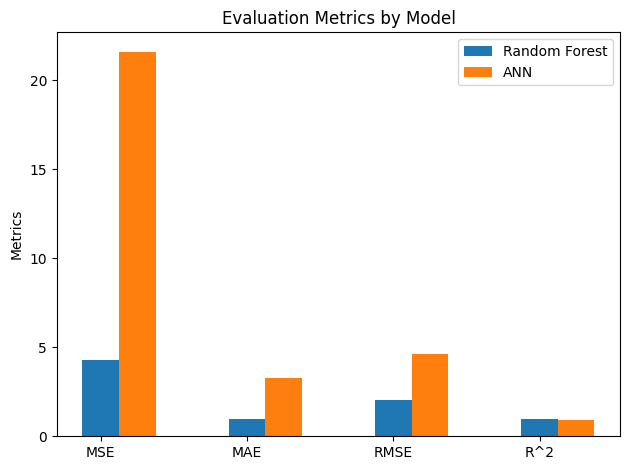

In [102]:
labels = ['MSE', 'MAE', 'RMSE', 'R^2']
rfGS_metrics = [rfGS_mse, rfGS_mae, rfGS_rmse, rfGS_r2]
annGS_metrics = [annGS_mse, annGS_mae, annGS_rmse, annGS_r2]

x = np.arange(len(labels))
width = 0.25

fig, ax = plt.subplots()
rects1 = ax.bar(x, rfGS_metrics, width, label='Random Forest')
rects2 = ax.bar(x + width, annGS_metrics, width, label='ANN')

ax.set_ylabel('Metrics')
ax.set_title('Evaluation Metrics by Model')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

fig.tight_layout()

plt.show()

print()

## Overall Performance Comparison

Across all models evaluated—ranging from linear models to ensemble tree-based regressors and artificial neural networks—there was a consistent trend of improved performance with increased model complexity and targeted hyperparameter tuning

### Baseline and Linear Models
- Dummy Regressor served as a reference baseline and performed poorly, as expected, with high MAE and near-zero $R^2$
- Linear Regression, Ridge, and ElasticNet all achieved strong performance, with validation $R^2 \approx 0.82$, indicating that much of the relationship between features and `pm` is linearly explainable
- SVR outperformed all linear models, achieving the lowest validation MAE and best generalization among baseline regressors, highlighting the benefit of modeling non-linear relationships

### Random Forest Regressor (RFR)
- All Random Forest configurations significantly outperformed baseline regressors, achieving validation $R^2 > 0.98$
- Grid Search optimization provided the best overall performance with the lowest MAE and MSE on both validation and test sets
- Bayesian Optimization was competitive with slightly fewer estimators, making it a more efficient option in compute-constrained settings
- **Key insight:** Ensemble models effectively captured complex feature interactions and non-linearities in the data

### Artificial Neural Networks (ANN)
- The Vanilla ANN configuration underperformed, demonstrating the importance of proper architecture and training configuration
- Grid Search optimization led to the best overall performance across all models, with a test $R^2$ of 0.939, lowest MAE and RMSE, and well-balanced training-validation error
- Bayesian Optimization again showed strong performance with slightly less training and a higher learning rate, indicating faster convergence
- **Key insight:** When properly tuned, ANNs can outperform both linear and tree-based models, particularly when modeling complex, high-dimensional relationships

## Key Takeaways

- **Hyperparameter tuning:** Improves model performance for both RFR and ANN
- **SVR and Random Forest:** Provide strong out-of-the-box performance with minimal tuning, making them solid initial choices
- **ANNs:** Require careful design and tuning to achieve top-tier performance
- **Regularization techniques:** (Ridge, Lasso, ElasticNet) helped improve generalization in linear models, though they were ultimately limited by their inability to capture non-linearity

## Final Recommendation

- For maximum accuracy and if computational resources allow, the **Grid Search ANN** is recommended
- For a more interpretable and faster alternative with competitive performance, the **Grid Search Random Forest** offers a strong trade-off
- When quick baselines are needed, **SVR** or **Ridge Regression** are suitable starting points.
